# #30DayMapChallenge - Día 6: Raster
## Caso de Negocio: Álgebra de mapas para ubicar naves logísticas

**Autor:** Mario Ignacio Ibañez Castro | **Rol:** Data Scientist & Strategic Planner

### El objetivo
Hasta ahora trabajamos vectores (puntos, líneas, polígonos). Hoy entramos al mundo **raster**: una matriz donde cada celda es un valor continuo —en este caso, **elevación**.

Para logística en el Valle de México, la topografía no es decorado:
- Pendiente alta → costo de construcción, acceso de trailers, drenaje.
- Fondos de vaso lacustre → riesgo hídrico histórico (la ciudad se hundió sobre un lago).

**Pregunta de negocio:** ¿Dónde combinar *pendiente baja* + *fuera de la zona más baja del valle* para candidatos de nave / dark store?

**Reto técnico:** Álgebra de mapas y procesamiento matricial (DEM → slope → índice de aptitud).

**Fuente de Datos:** DEM vía tiles Terrarium (AWS/Mapzen, basados en SRTM/NASA) — `00_Datos/dem_cdmx_srtm_proxy.tif`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from pathlib import Path
import contextily as ctx

plt.style.use('dark_background')
%matplotlib inline

RUTA_DATOS = Path('../00_Datos')
CARPETA_SALIDA = Path('.')
DEM_PATH = RUTA_DATOS / 'dem_cdmx_srtm_proxy.tif'

### 1. Ingesta del DEM
Un raster es un arreglo NumPy + un *geotransform* que lo ancla al planeta. Leemos elevación en metros sobre el nivel del mar.

In [2]:
with rasterio.open(DEM_PATH) as src:
    dem = src.read(1).astype(np.float32)
    nodata = src.nodata
    transform = src.transform
    crs = src.crs
    bounds = src.bounds
    profile = src.profile.copy()

if nodata is not None:
    dem = np.where(dem == nodata, np.nan, dem)

print(f'Shape: {dem.shape}  |  CRS: {crs}')
print(f'Bounds: {bounds}')
print(f'Elevación: {np.nanmin(dem):.0f} – {np.nanmax(dem):.0f} m')
print(f'Media / mediana: {np.nanmean(dem):.0f} / {np.nanmedian(dem):.0f} m')

Shape: (512, 512)  |  CRS: EPSG:4326
Bounds: BoundingBox(left=-99.4921875, bottom=18.97902595325527, right=-98.7890625, top=19.642587534013032)
Elevación: 1626 – 3909 m
Media / mediana: 2594 / 2481 m


/tmp/ipykernel_130465/585424445.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dem = src.read(1).astype(np.float32)


### 2. Mapa de elevación (el raster crudo)
Primera lectura visual del relieve del Valle de México: piso urbano ~2,200 m y sierras que rozan los 3,500–3,900 m.

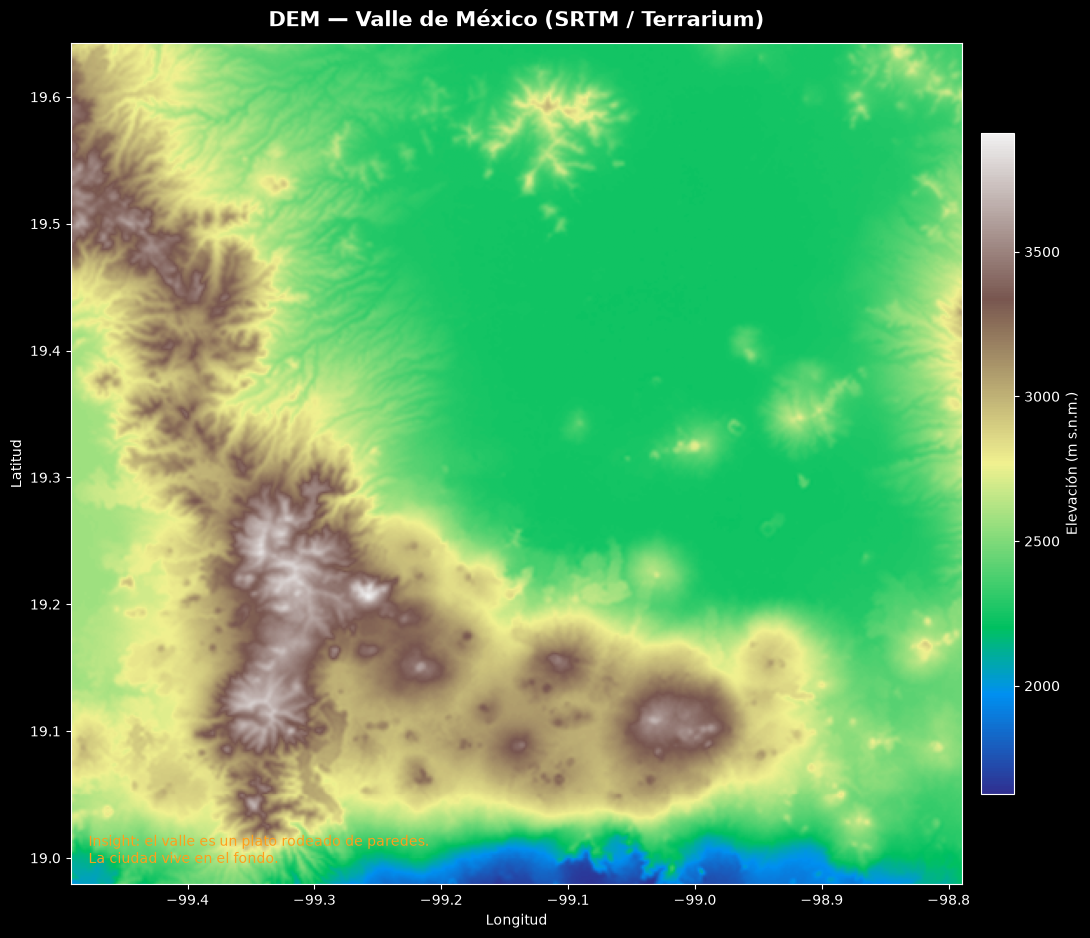

Guardado: Dia6_DEM_Elevacion.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor('black')

extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
im = ax.imshow(dem, extent=extent, origin='upper', cmap='terrain', alpha=0.95)
cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Elevación (m s.n.m.)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

ax.set_title('DEM — Valle de México (SRTM / Terrarium)', fontsize=15, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Longitud', color='white')
ax.set_ylabel('Latitud', color='white')
ax.tick_params(colors='white')
ax.text(
    0.02, 0.02,
    'Insight: el valle es un plato rodeado de paredes.\nLa ciudad vive en el fondo.',
    transform=ax.transAxes, color='#FF9F1C', fontsize=10, va='bottom'
)

plt.tight_layout()
plt.savefig(CARPETA_SALIDA / 'Dia6_DEM_Elevacion.png', dpi=170, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia6_DEM_Elevacion.png')

### 3. Álgebra de mapas I — Pendiente (slope)
La pendiente se deriva del gradiente espacial del DEM.

$$
\text{slope} = \arctan\sqrt{\left(\frac{\partial z}{\partial x}\right)^2 + \left(\frac{\partial z}{\partial y}\right)^2}
$$

En grados. Es el primer "mapa derivado" del relieve —clave para costo de acceso.

In [4]:
# Tamaño de celda en metros (aprox. en latitud de CDMX)
# 1° lat ≈ 111_320 m; 1° lon ≈ 111_320 * cos(lat)
lat_ref = (bounds.top + bounds.bottom) / 2
res_x_deg = transform.a  # ancho de píxel en grados (positivo)
res_y_deg = abs(transform.e)  # alto de píxel en grados

dx_m = abs(res_x_deg) * 111_320 * np.cos(np.radians(lat_ref))
dy_m = abs(res_y_deg) * 111_320

# Gradientes: np.gradient usa eje 0 = filas (y), eje 1 = columnas (x)
dz_dy, dz_dx = np.gradient(dem, dy_m, dx_m)
slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
slope_deg = np.degrees(slope_rad)

print(f'Resolución aprox.: {dx_m:.0f} m x {dy_m:.0f} m')
print(f'Pendiente: {np.nanmin(slope_deg):.2f}° – {np.nanmax(slope_deg):.2f}°')
print(f'Pendiente media: {np.nanmean(slope_deg):.2f}°')

Resolución aprox.: 144 m x 144 m
Pendiente: 0.00° – 46.18°
Pendiente media: 6.34°


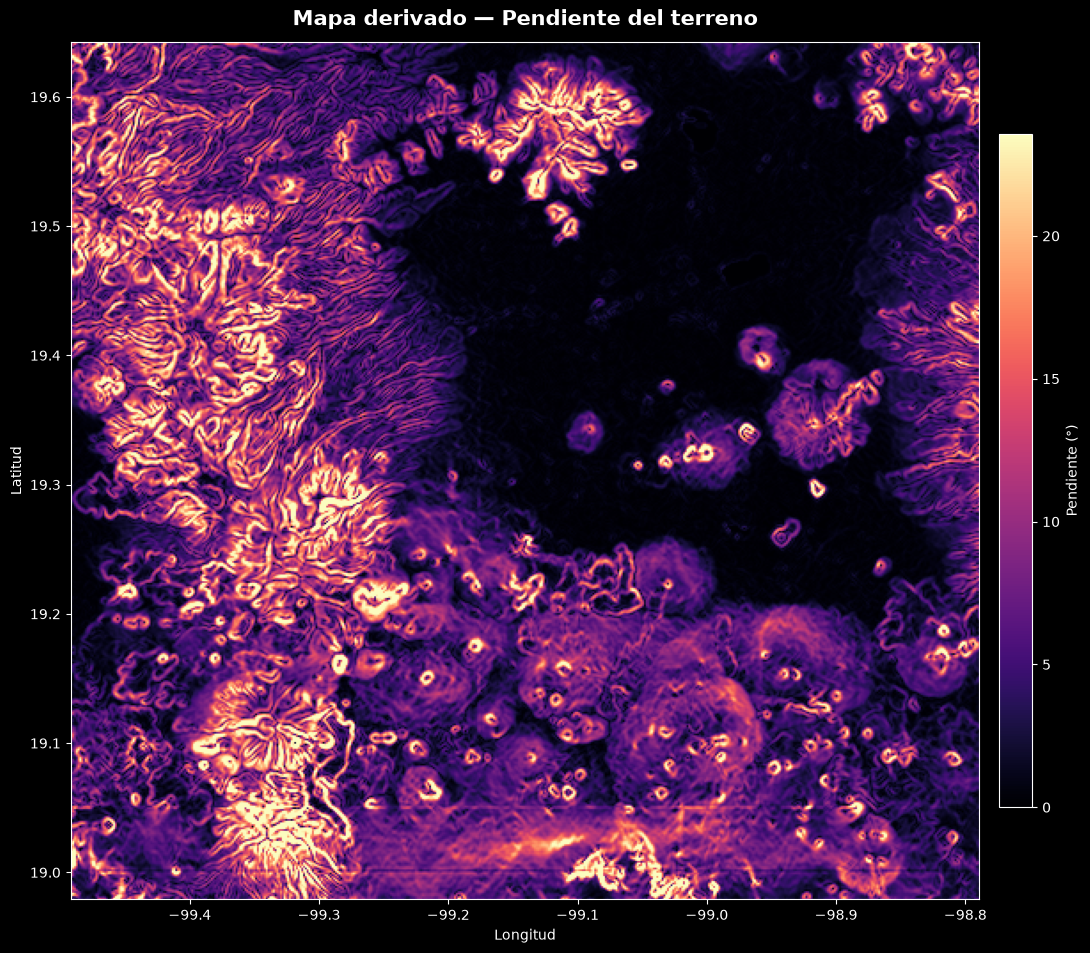

Guardado: Dia6_Pendiente.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor('black')

# Capamos visualmente extremos para no saturar con acantilados
vmax = np.nanpercentile(slope_deg, 98)
im = ax.imshow(slope_deg, extent=extent, origin='upper', cmap='magma', vmin=0, vmax=vmax)
cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Pendiente (°)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

ax.set_title('Mapa derivado — Pendiente del terreno', fontsize=15, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Longitud', color='white')
ax.set_ylabel('Latitud', color='white')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig(CARPETA_SALIDA / 'Dia6_Pendiente.png', dpi=170, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia6_Pendiente.png')

### 4. Álgebra de mapas II — Índice de aptitud logística
Combinamos capas con operaciones matriciales (el corazón del día):

1. **Pendiente favorable:** slope ≤ 5° (tráiler + construcción barata).
2. **Fuera del vaso más bajo:** elevación ≥ percentil 35 del DEM válido (evita el fondo lacustre más hundido).
3. **No montaña:** elevación ≤ percentil 85 (descarta laderas altas / sierras).

$$
\text{aptitud} = \mathbf{1}_{slope \le 5°} \cdot \mathbf{1}_{p35 \le z \le p85}
$$

Resultado binario → máscara de candidatos.

In [6]:
z = dem
p35 = np.nanpercentile(z, 35)
p85 = np.nanpercentile(z, 85)

mask_slope = slope_deg <= 5
mask_elev = (z >= p35) & (z <= p85)
aptitud = (mask_slope & mask_elev).astype(np.float32)
aptitud[np.isnan(z)] = np.nan

pct_apto = np.nanmean(aptitud) * 100
print('=== ÁLGEBRA DE MAPAS — REGLAS ===')
print(f'Umbral elevación baja (p35): {p35:.0f} m')
print(f'Umbral elevación alta (p85): {p85:.0f} m')
print(f'Celdas aptas: {pct_apto:.1f}% del raster válido')

# Score continuo opcional (0-1) para mapa más rico
# Normalizamos pendiente (invertida) y elevación (campana entre p35-p85)
slope_score = np.clip(1 - (slope_deg / 15), 0, 1)  # 0°→1, 15°→0
elev_mid = (p35 + p85) / 2
elev_half = (p85 - p35) / 2
elev_score = np.clip(1 - np.abs(z - elev_mid) / elev_half, 0, 1)
score = slope_score * elev_score
score[np.isnan(z)] = np.nan

print(f'Score medio: {np.nanmean(score):.3f}')

=== ÁLGEBRA DE MAPAS — REGLAS ===
Umbral elevación baja (p35): 2323 m
Umbral elevación alta (p85): 3064 m
Celdas aptas: 19.1% del raster válido
Score medio: 0.123


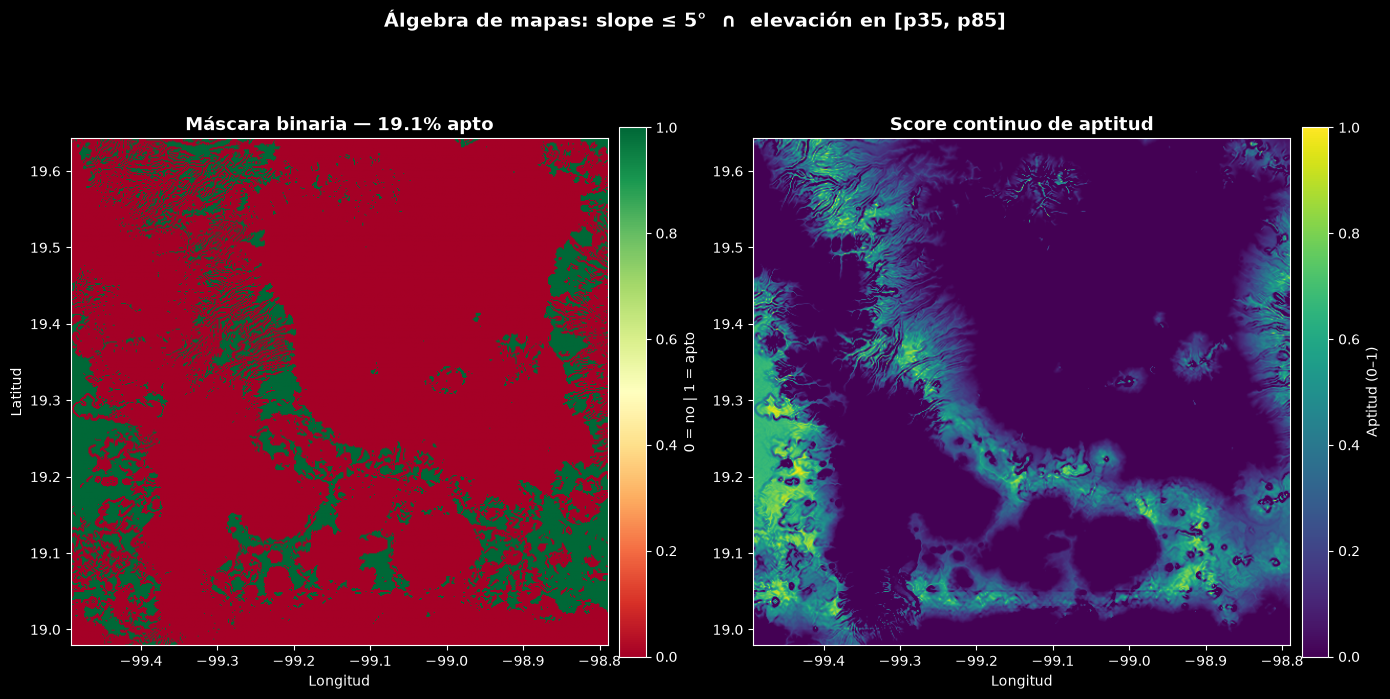

Guardado: Dia6_Aptitud_Algebra.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('black')

ax0 = axes[0]
im0 = ax0.imshow(aptitud, extent=extent, origin='upper', cmap='RdYlGn', vmin=0, vmax=1)
ax0.set_title(f'Máscara binaria — {pct_apto:.1f}% apto', fontsize=13, fontweight='bold', color='white')
ax0.set_xlabel('Longitud', color='white')
ax0.set_ylabel('Latitud', color='white')
ax0.tick_params(colors='white')
cbar0 = plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.02)
cbar0.set_label('0 = no | 1 = apto', color='white')
cbar0.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar0.ax.axes, 'yticklabels'), color='white')

ax1 = axes[1]
im1 = ax1.imshow(score, extent=extent, origin='upper', cmap='viridis', vmin=0, vmax=1)
ax1.set_title('Score continuo de aptitud', fontsize=13, fontweight='bold', color='white')
ax1.set_xlabel('Longitud', color='white')
ax1.tick_params(colors='white')
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)
cbar1.set_label('Aptitud (0–1)', color='white')
cbar1.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar1.ax.axes, 'yticklabels'), color='white')

fig.suptitle(
    'Álgebra de mapas: slope ≤ 5°  ∩  elevación en [p35, p85]',
    fontsize=14, fontweight='bold', color='white', y=1.02
)

plt.tight_layout()
plt.savefig(CARPETA_SALIDA / 'Dia6_Aptitud_Algebra.png', dpi=170, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia6_Aptitud_Algebra.png')

### 5. Mapa final de negocio
Reproyectamos el score a Web Mercator y lo superponemos sobre un basemap para comunicar el hallazgo a stakeholders no GIS.

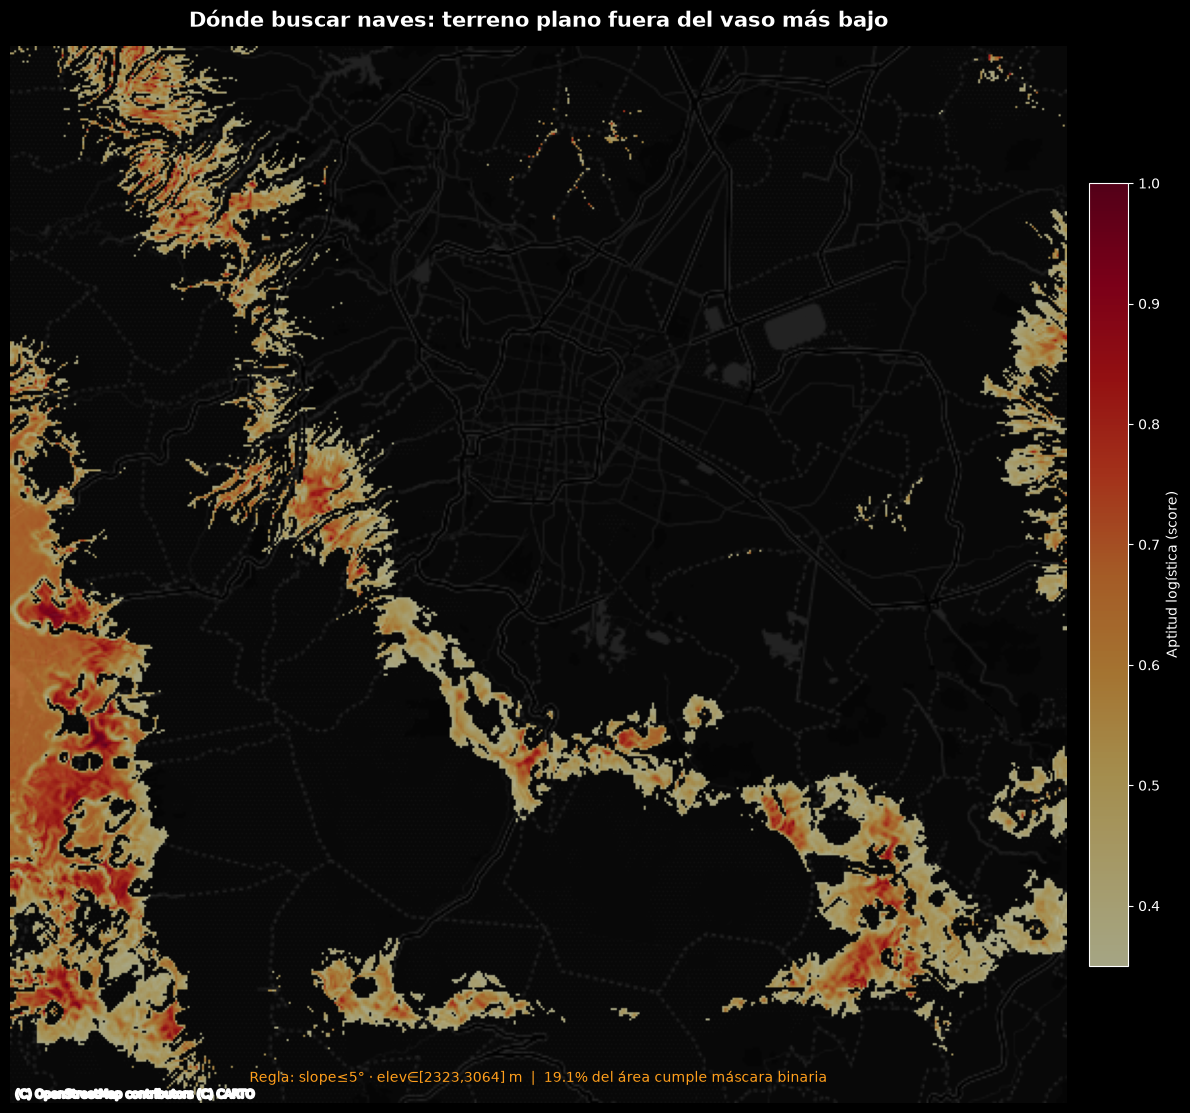

Guardado: Dia6_Mapa_Final_Aptitud.png


In [8]:
# Reproyectar score a EPSG:3857 para contextily
dst_crs = 'EPSG:3857'
with rasterio.open(DEM_PATH) as src:
    transform3857, w3857, h3857 = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    score_3857 = np.empty((h3857, w3857), dtype=np.float32)
    reproject(
        source=score.astype(np.float32),
        destination=score_3857,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform3857,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    left, bottom, right, top = array_bounds(h3857, w3857, transform3857)

# Enmascarar valores bajos para que el basemap se lea debajo
score_plot = np.ma.masked_where(np.isnan(score_3857) | (score_3857 < 0.35), score_3857)

fig, ax = plt.subplots(figsize=(12, 12))
fig.patch.set_facecolor('black')
ax.set_xlim(left, right)
ax.set_ylim(bottom, top)

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.DarkMatterNoLabels,
        zoom_adjust=0,
        alpha=0.9,
        zorder=1,
    )
except Exception as e:
    print(f'Basemap no disponible ({e}).')

im = ax.imshow(
    score_plot,
    extent=[left, right, bottom, top],
    origin='upper',
    cmap='YlOrRd',
    alpha=0.65,
    zorder=2,
    vmin=0.35,
    vmax=1.0,
)
cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Aptitud logística (score)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

ax.set_axis_off()
ax.set_title(
    'Dónde buscar naves: terreno plano fuera del vaso más bajo',
    fontsize=15, fontweight='bold', color='white', pad=14
)
ax.text(
    0.5, 0.02,
    f'Regla: slope≤5° · elev∈[{p35:.0f},{p85:.0f}] m  |  {pct_apto:.1f}% del área cumple máscara binaria',
    transform=ax.transAxes, ha='center', fontsize=10, color='#FF9F1C'
)

plt.tight_layout()
plt.savefig(CARPETA_SALIDA / 'Dia6_Mapa_Final_Aptitud.png', dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia6_Mapa_Final_Aptitud.png')

### 6. Panel resumen (elevación → pendiente → decisión)
El flujo raster completo en una sola figura para LinkedIn / reporte ejecutivo.

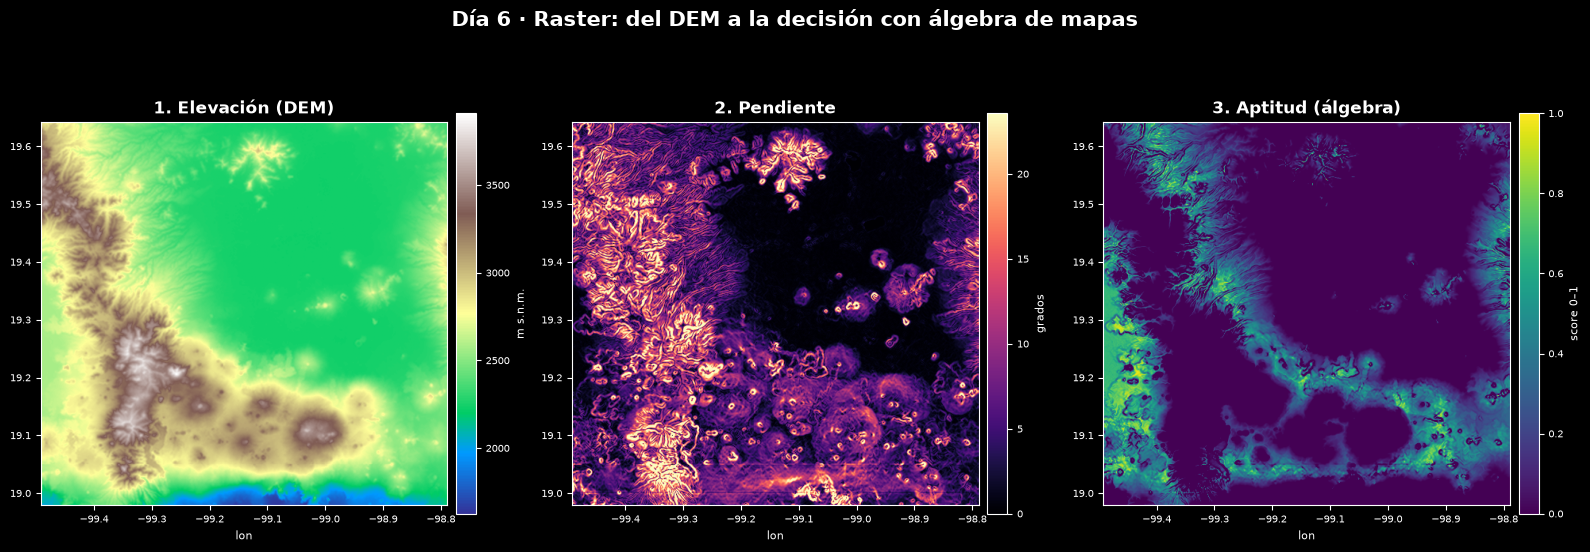

Guardado: Dia6_Panel_Resumen.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.patch.set_facecolor('black')

panels = [
    (dem, 'terrain', '1. Elevación (DEM)', 'm s.n.m.', None, None),
    (slope_deg, 'magma', '2. Pendiente', 'grados', 0, vmax),
    (score, 'viridis', '3. Aptitud (álgebra)', 'score 0–1', 0, 1),
]

for ax, (data, cmap, title, label, vmin, vmax_) in zip(axes, panels):
    im = ax.imshow(data, extent=extent, origin='upper', cmap=cmap, vmin=vmin, vmax=vmax_)
    ax.set_title(title, fontsize=12, fontweight='bold', color='white')
    ax.tick_params(colors='white', labelsize=7)
    ax.set_xlabel('lon', color='white', fontsize=8)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label(label, color='white', fontsize=8)
    cbar.ax.yaxis.set_tick_params(color='white', labelsize=7)
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

fig.suptitle(
    'Día 6 · Raster: del DEM a la decisión con álgebra de mapas',
    fontsize=15, fontweight='bold', color='white', y=1.02
)
plt.tight_layout()
plt.savefig(CARPETA_SALIDA / 'Dia6_Panel_Resumen.png', dpi=170, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia6_Panel_Resumen.png')

### 7. Insight de negocio
Un DEM no es un mapa bonito de montañas: es un **insumo de costo y riesgo**.

- Sin álgebra de mapas, el equipo de expansion "elige a ojo".
- Con slope + elevación, filtras decenas de km² antes de mirar precio de suelo o DENUE.
- El siguiente paso natural: intersectar la máscara apta con AGEBs / predios / precio (vector × raster).

**Regla práctica:** todo modelo de ubicación en CDMX debería preguntarle algo al relieve.

### Regenerar el DEM
```bash
python ../00_Datos/descargarDEM.py
```

In [10]:
# Exportar rasters derivados para reutilizar
out_slope = RUTA_DATOS / 'slope_cdmx_deg.tif'
out_score = RUTA_DATOS / 'aptitud_logistica_score.tif'

for path, arr in [(out_slope, slope_deg), (out_score, score)]:
    prof = profile.copy()
    prof.update(dtype='float32', nodata=-9999, compress='lzw')
    data = np.where(np.isnan(arr), -9999, arr).astype(np.float32)
    with rasterio.open(path, 'w', **prof) as dst:
        dst.write(data, 1)
    print(f'Exportado: {path}')

print('Día 6 completado.')

Exportado: ../00_Datos/slope_cdmx_deg.tif
Exportado: ../00_Datos/aptitud_logistica_score.tif
Día 6 completado.
